In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/telco_clean.csv')

### Cleaning

In [3]:
cols_to_drop = ['customerID', 'gender', 'PhoneService', 'MultipleLines', 'StreamingTV', 'StreamingMovies','TotalCharges']

df = df.drop(columns=cols_to_drop)
print(df.shape)

(7043, 15)


In [4]:
print(df.columns.tolist())

['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'Churn', 'auto_payment']


### Encoding | X/y separation

In [5]:
# Encode the target as binary
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# Separate features and target
X = df.drop(columns=['Churn'])
y = df['Churn']

print(f"Shape X : {X.shape}")
print(f"Positifs (Churn=1) : {y.sum()} ({y.mean():.1%})")

Shape X : (7043, 14)
Positifs (Churn=1) : 1869 (26.5%)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# stratify=y to preserve ratio in both splits
print(f"Train : {X_train.shape[0]} lines")
print(f"Test  : {X_test.shape[0]} lines")
print(f"Churn in train : {y_train.mean():.1%}")
print(f"Churn in test  : {y_test.mean():.1%}")

Train : 5634 lines
Test  : 1409 lines
Churn in train : 26.5%
Churn in test  : 26.5%


In [7]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Automatically identify columns by data type
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

# Numerical pipeline (StandardScaler since there are no outliers)
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline (OneHotEncoder suited for nominal variables)
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    # handle_unknown='ignore' avoids errors if a new category appears later
])

# Combine in the ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# Verification
X_train_transformed = preprocessor.fit_transform(X_train)
print(f"Initial X_train shape: {X_train.shape}")
print(f"Shape after preprocessing: {X_train_transformed.shape}")

Initial X_train shape: (5634, 14)
Shape after preprocessing: (5634, 32)


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_validate
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import seaborn as sns

# transform the test set
X_test_transformed = preprocessor.transform(X_test)

xgb_ratio = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    'Logistic Regression (Normal)':   LogisticRegression(max_iter=1000, random_state=42),
    'Logistic Regression (Balanced)': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest (Normal)':         RandomForestClassifier(n_estimators=100, random_state=42),
    'Random Forest (Balanced)':       RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42),
    'XGBoost (Normal)':               XGBClassifier(random_state=42, eval_metric='logloss'),
    'XGBoost (Balanced)':             XGBClassifier(scale_pos_weight=xgb_ratio, random_state=42, eval_metric='logloss'),
    'LightGBM (Normal)':              LGBMClassifier(random_state=42, verbose=-1),
    'LightGBM (Balanced)':            LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1)
}

In [9]:
from IPython.display import display
# Compare models with CrossValidation on X_train only (test set not touched)
cv = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=42
)
cv_results = []
for name, model in models.items():
    scores = cross_validate(
        model, X_train_transformed, y_train,
        cv=cv,
        scoring={
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc"
        }
    )
    cv_results.append({
        "Model": name,
        "Recall CV": round(scores["test_recall"].mean(), 3),
        "F1 CV": round(scores["test_f1"].mean(), 3),
        "ROC-AUC CV": round(scores["test_roc_auc"].mean(), 3)
    })

cv_df = pd.DataFrame(cv_results).sort_values('F1 CV', ascending=False)
numeric_cols = cv_df.select_dtypes(include="number").columns
display(cv_df.style.format({col: "{:.3f}" for col in numeric_cols}).hide(axis="index"))

c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWa

Model,Recall CV,F1 CV,ROC-AUC CV
LightGBM (Balanced),0.751,0.635,0.838
Logistic Regression (Balanced),0.794,0.625,0.843
XGBoost (Balanced),0.655,0.595,0.823
Logistic Regression (Normal),0.537,0.590,0.843
LightGBM (Normal),0.526,0.579,0.837
XGBoost (Normal),0.523,0.567,0.822
Random Forest (Normal),0.487,0.542,0.809
Random Forest (Balanced),0.475,0.539,0.808


the F1-Score is a concrete metric to sort by (it depends on the current operational threshold) and it avoids the trap of the “false good Recall” (a paranoid model which predicts churn everywhere)

c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Best model : LightGBM (Balanced)

              precision    recall  f1-score   support

    No Churn       0.89      0.76      0.82      1035
       Churn       0.52      0.74      0.61       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.79      0.75      0.76      1409

Recall : 0.738
F1-score : 0.612
AUC-ROC : 0.833


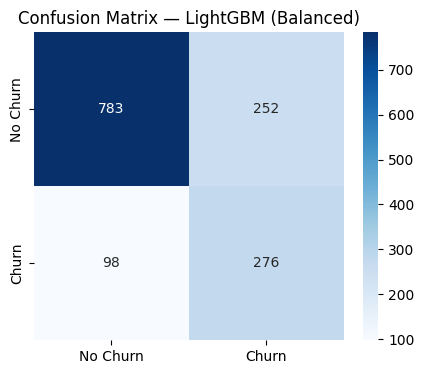

Best model : Logistic Regression (Balanced)

              precision    recall  f1-score   support

    No Churn       0.90      0.71      0.80      1035
       Churn       0.50      0.79      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.73      0.75      1409

Recall : 0.789
F1-score : 0.610
AUC-ROC : 0.836


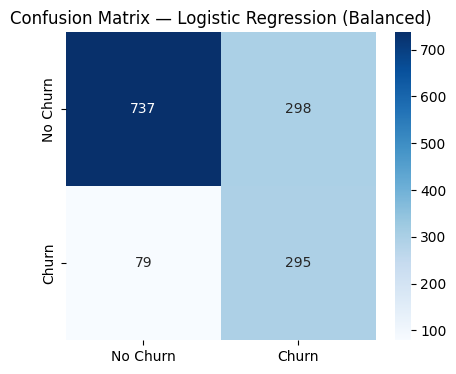

In [10]:
from sklearn.metrics import recall_score, f1_score
import matplotlib.pyplot as plt

test_results = []
# Re-train the 2 winners on full X_train
for i in range(2):
    best_model_name = cv_df.iloc[i]['Model']
    best_model = models[best_model_name]
    
    best_model.fit(X_train_transformed, y_train)
    
    # Evaluate on test set
    y_pred  = best_model.predict(X_test_transformed)
    y_proba = best_model.predict_proba(X_test_transformed)[:, 1]

    test_results.append({
        "Model": best_model_name,
        "Recall": round(recall_score(y_test, y_pred), 3),
        "F1": round(f1_score(y_test, y_pred), 3),
        "ROC-AUC": round(roc_auc_score(y_test, y_proba), 3)
    })
    
    print(f"Best model : {best_model_name}\n")
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
    print(f"Recall : {recall_score(y_test, y_pred):.3f}")
    print(f"F1-score : {f1_score(y_test, y_pred):.3f}")
    print(f"AUC-ROC : {roc_auc_score(y_test, y_proba):.3f}")
    
    # confusion matrix
    plt.figure(figsize=(5, 4))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    plt.title(f'Confusion Matrix — {best_model_name}')
    plt.show()

In [11]:
comparison_df = (
    pd.DataFrame(test_results)
      .set_index("Model")
      .T
)

display(comparison_df)

Model,LightGBM (Balanced),Logistic Regression (Balanced)
Recall,0.738,0.789
F1,0.612,0.610
ROC-AUC,0.833,0.836


Cross-validation showed that LightGBM (Balanced) and Logistic Regression (Balanced) were the two best-performing models. 

They were then retrained on the entire training dataset and evaluated once on the test dataset. 

Since the final performance results were very close, the choice of model depends on the **business objective** :
prioritizing recall to detect as many churners as possible (Logistic Regression) or a better balance between precision and recall (LightGBM).

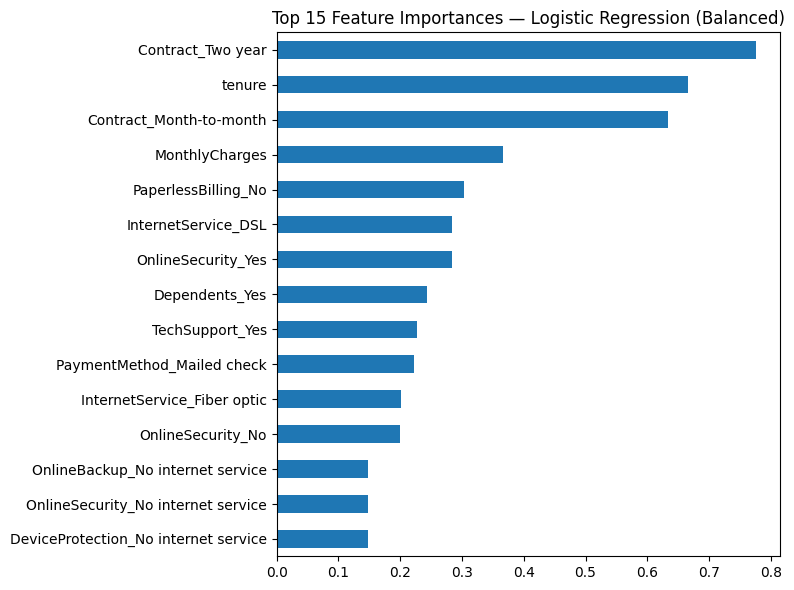

In [14]:
# Get feature names after OneHotEncoder
clmn_names = preprocessor.named_transformers_['cat'] \
                         .named_steps['encoder'] \
                         .get_feature_names_out(cat_cols).tolist()
feature_names = num_cols + clmn_names

# Handle LR (coef_) vs tree models (feature_importances_)
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=feature_names)
else:
    importances = pd.Series(best_model.coef_[0], index=feature_names).abs()

importances = importances.sort_values(ascending=False)

importances.head(15).plot(kind='barh', figsize=(8, 6))
plt.title(f'Top 15 Feature Importances — {best_model_name}')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

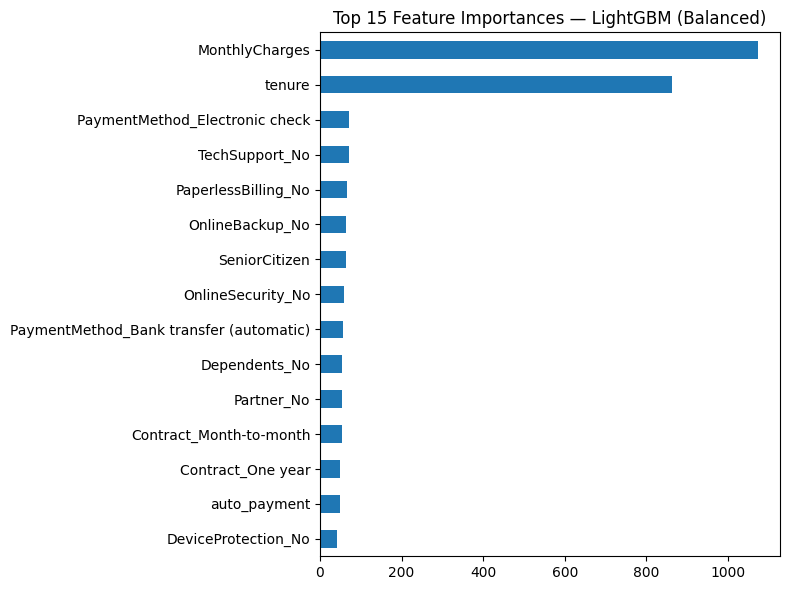

In [13]:
lgbm_model = models['LightGBM (Balanced)']

# Already fitted in the loop — just extract importances
importances_lgbm = pd.Series(lgbm_model.feature_importances_, index=feature_names)
importances_lgbm = importances_lgbm.sort_values(ascending=False)

importances_lgbm.head(15).plot(kind='barh', figsize=(8, 6))
plt.title('Top 15 Feature Importances — LightGBM (Balanced)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Feature Importance

Both models agree on the two strongest predictors : **tenure** and **MonthlyCharges**.

LR highlights **Contract type** as the top feature — customers on a Two-year 
contract have a strong negative coefficient for churn. LightGBM absorbs this 
signal into tenure (long-tenure customers tend to be on longer contracts).

The engineered feature **auto_payment** appears in LightGBM's top 15, 
confirming it adds predictive value beyond PaymentMethod alone.

→ High-risk profile confirmed : recent customer (low tenure) + high monthly 
charges + no long-term contract + electronic check payment.

In [15]:
import joblib
import os

os.makedirs('models', exist_ok=True)

# Sauvegarder le preprocessor
joblib.dump(preprocessor, 'models/preprocessor.pkl')

# Sauvegarder les 2 gagnants
top2 = cv_df.head(2)['Model'].tolist()

for name in top2:
    model = models[name]
    filename = name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    joblib.dump(model, f'models/{filename}.pkl')
    print(f"Saved : {filename}.pkl")

Saved : lightgbm_balanced.pkl
Saved : logistic_regression_balanced.pkl


### Saved Models

Two models are saved depending on the business objective :
- `lightgbm_balanced.pkl` → better overall balance (F1)
- `logistic_regression_balanced.pkl` → higher Recall, more interpretable

Choose based on whether the priority is catching maximum churners 
or minimizing unnecessary retention offers.